# Lab 4\. Building the Full Transform Pipeline

## Overview

Across the previous labs you built the front half of a PyTorch data pipeline: an **Imagenette** Dataset that returns **(image, label)** samples, and a **DataLoader** that groups samples into batches. You also hit a wall. When you first pointed a DataLoader at the raw dataset, it could not build a single batch, because the images were variable-sized PIL images and PIL images cannot be stacked into one tensor. In Lab 3 you worked around that limitation with a minimal preview transform.

In this lab you will apply the essential **torchvision.transforms.v2** transforms one at a time to a real Imagenette image and watch the type, shape, and values change at each step; compose them into a single preprocessing pipeline; add the augmentation transforms that make training data more varied; reproduce three data-preparation failures so you can recognize their symptoms; and finally assemble the complete training and validation pipelines that feed a training and a validation DataLoader. When you finish, you will have the full data handling pipeline this course set out to build, running end to end in your notebook.

This is the shape every real training script takes. Getting the transforms right, and keeping them consistent between training and evaluation, is the difference between a pipeline that feeds a model clean, uniform data and one that quietly corrupts your results. The failures you will reproduce here are the ones that do not crash your program; they degrade it silently, and knowing their symptoms is what lets you catch them in your own work.

## Learning Objectives

By the end of this lab, you should be able to:

* Apply the **v2.ToImage**, **v2.ToDtype**, **v2.Resize**, and **v2.Normalize** transforms to a sample and inspect the result at each step

* Combine transforms into a single pipeline with **v2.Compose**

* Add the **v2.RandomHorizontalFlip** and **v2.RandomRotation** augmentation transforms and observe their randomness

* Identify the data-level symptoms of unnormalized data, mismatched train/evaluation transforms, and a shape mismatch

* Assemble separate training and validation transform pipelines and wire them into a training and a validation DataLoader

## Prerequisites

This course’s labs are **not cumulative**, so this lab does not depend on any prior resources or the state of earlier labs if there are any.   
You need the following before you start:

* **A notebook environment:** either a Google account for Google Colab, or a local installation of Jupyter Notebook. Every step in this lab runs on a CPU; no GPU is required.

* **Python 3.12 or later.** On Colab this is already provided. For a local environment, confirm your version with **python \--version**.

* **PyTorch 2.12.1 and TorchVision 0.17 or later (0.27 preferred),** installed with **pip** in the previous lab. If you are on Colab, these may already be present. The **Imagenette** dataset requires torchvision 0.17 or newer.

* **matplotlib**, used once to display augmented images.

* **A web browser** (Chrome, Firefox, or Edge are recommended for Colab).

## Estimated Time

45–60 minutes.

## How to Perform the Exercise

You will work entirely in one notebook, running cells from top to bottom. Create a new notebook in Google Colab (**File \> New notebook**) or a new **.ipynb** in local Jupyter. Download the chapter 4 lab notebook from the [LFD2001-resources GitHub repository](https://github.com/lftraining/LFD2001-resources.git) from the **LFD2001-resources/labs** directory. In Google Colab, select File, then Upload Notebook, and select the chapter 4 lab notebook you downloaded.

Read the explanation before running each cell, run it, and compare what you see to the **Sample Output** or **Output** shown after each block. Sample Output means the exact values will differ from run to run (random tensors, dataset counts, file paths), so match the shape and structure rather than every character. Output marks a checkpoint where a specific outcome confirms the step worked.

Commands in this lab use the notebook form, where a line beginning with **\!** runs a shell command from inside a notebook cell (for example, **\!pip install ...**). If you run these in a local terminal instead of a notebook cell, drop the leading **\!**.

> **Note:** Run the cells in order and only once each, unless a step says otherwise. If you restart the notebook's runtime, re-run the cells from the top, because the variables live in memory and are cleared on restart.

## Setup: Environment Preparation

The steps in this section only prepare the environment. They are not the learning content of the lab, and on a managed course platform some of them may already be done for you. Run them once at the top of your notebook, then move on to Step 1\.

### Setup 1\. Import the libraries

Bring in the pieces this lab uses. **Imagenette** is the dataset class from Lab 2, **v2** is the transform module from Lab 3, **DataLoader** is the batching tool from Lab 3, **torch** supplies the numeric type you will pass to **ToDtype**, and **matplotlib.pyplot** is used later to display augmented images.


In [ ]:
from torchvision.datasets import Imagenette
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import torch
import matplotlib.pyplot as plt


This cell produces no output. If it runs without an **ImportError**, your environment has the libraries this lab needs.

### Setup 2\. Load a raw sample to work with

The first sections of this lab apply transforms to a single raw image so you can see exactly what each one does. Load the training split without any transform, the way you first did in Lab 2, so its images come back as PIL images, and pull out the first sample.


In [ ]:
raw_data = Imagenette(root="data", split="train", size="160px", download=True)
print(len(raw_data))

image, label = raw_data[0]
print(type(image), image.size, "label:", label)


The **download=True** argument re-fetches the dataset only if it is not already in **data/**, so on a machine that still has it from Lab 2 nothing is downloaded. The **image.size** value is a **(width, height)** pair that differs from one sample to the next, because Imagenette photos are not a single fixed size.

**Sample Output:**

```
9469
<class 'PIL.Image.Image'> (213, 160) label: 0
```

The training split holds 9,469 samples, the image is a PIL image, and label **0** is the first class, **tench**.

## Section 1: Applying the Essential Transforms

This section applies each essential transform on its own, so you see one change at a time, then combines them with **v2.Compose**. Work on the single **image** you just loaded.

### Step 1\. Convert the PIL image to a tensor with **ToImage**

A model does its arithmetic on tensors, so the first job is to turn the PIL image into one. The **v2.ToImage** transform performs exactly this conversion and changes nothing else.


In [ ]:
to_image = v2.ToImage()
tensor_image = to_image(image)

print(type(tensor_image))
print(tensor_image.shape)
print(tensor_image.dtype)


The result is a TorchVision image tensor with three dimensions in **\[channels, height, width\]** order. Its values are still 8-bit integers (**uint8**) in the original 0-to-255 range, so the conversion changed the container, not the numbers.

**Sample Output:**

```
<class 'torchvision.tv_tensors._image.Image'>
torch.Size([3, 160, 213])
torch.uint8
```

The shape is now channels-first, and the height and width came from the original photo. \[\]

### Step 2\. Give every image one fixed shape with **Resize**

The tensor is a scaled float, but its height and width still come from the original photo, so different samples still have different shapes. **v2.Resize** forces every image to the same spatial size, which is what finally lets images stack into a batch.


In [ ]:
resize = v2.Resize((160, 160), antialias=True)
resized_image = resize(tensor_image)

print(resized_image.shape)


The first argument, **(160, 160\)**, is the target **(height, width)**, so every image comes out 160 by 160 no matter where it started. The **antialias=True** argument smooths the image as it is resized, which avoids jagged edges. The channel dimension is left alone.

**Output:**

```
torch.Size([3, 160, 160])
```

### Every image processed through this transform now has the identical shape **\[3, 160, 160\]**.

### Step 3\. Cast to scaled floats with ToDtype

The tensor holds integers from 0 to 255\. Models train more reliably on floating-point values in a small range, so convert the type and rescale in one transform. **v2.ToDtype** casts the tensor to the type you name, and with **scale=True** it also divides by 255 so the values land in 0.0 to 1.0.


In [ ]:
to_float = v2.ToDtype(torch.float32, scale=True)
float_image = to_float(resized_image)

print(float_image.dtype)
print(float_image.min().item(), float_image.max().item())


The first argument, **torch.float32**, is the target numeric type. The **scale=True** argument is what rescales the values as it converts; without it, the numbers would become floats but keep their 0-to-255 range.

**Sample Output:**

```
torch.float32
0.0 1.0
```

The values are now floats between 0.0 and 1.0.

### Step 4\. Center the values with Normalize

The image is now uniform and scaled, which is enough to train. Normalizing makes training more stable by recentering each channel's values around zero. **v2.Normalize** subtracts a mean and divides by a standard deviation, one value per color channel.


In [ ]:
normalize = v2.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
)
normalized_image = normalize(float_image)

print("mean=%.3f min=%.3f max=%.3f" % (
    normalized_image.mean().item(),
    normalized_image.min().item(),
    normalized_image.max().item(),
))


The **mean** and **std** lists carry one number per channel in red-green-blue order. These three values are the standard statistics computed over ImageNet, and because Imagenette is a subset of ImageNet they are the conventional choice for it. After normalizing, values are no longer bounded by 0 and 1; they spread above and below zero, which is the centered range models train best on. **Normalize** needs floating-point input, which is why it comes after **ToDtype**.

**Sample Output:**

```
mean=-0.297 min=-2.118 max=2.472
```

The mean is now near zero and the minimum is negative, which is correct.

> **Note:** **Normalize** does not return values to the 0-to-1 range. It recenters them around zero, so negative pixel values after normalizing are expected, not a bug.

### Step 5\. Chain the transforms with Compose

Applying four transforms one variable at a time is clear for learning but awkward in practice. **v2.Compose** chains a list of transforms into a single object that runs them in order, so you preprocess a sample with one call.


In [ ]:
preprocess = v2.Compose([
    v2.ToImage(),
    v2.Resize((160, 160), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

output = preprocess(image)
print(output.shape, output.dtype)


**Compose** takes a Python list and applies the transforms left to right: the output of **ToImage** feeds **Resize**, and so on. The order matters. **ToImage** is first because everything after it needs a tensor, and **Normalize** is last because it needs floats, which **ToDtype** produces.

**Output:**

```
torch.Size([3, 160, 160]) torch.float32
```

The single call **preprocess(image)** now does the whole conversion, producing a **\[3, 160, 160\]** float tensor.

## Section 2: Adding Data Augmentation

The transforms so far change every image the same way every time. Augmentation transforms change each image a little differently on each draw, on purpose, to give the model more variety to learn from. This section adds two of them and shows their randomness.

### Step 6\. Build an augmentation pipeline

**v2.RandomHorizontalFlip** flips an image left-to-right with a given probability, and **v2.RandomRotation** turns it by a random angle within a range. Combine them with **ToImage** so they operate on a tensor.


In [ ]:
augment = v2.Compose([
    v2.ToImage(),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=15),
])


For **RandomHorizontalFlip**, **p=0.5** is the probability that any given image is flipped, so on average half are flipped. For **RandomRotation**, passing the single number **15** rotates each image by a random angle chosen between **\-15** and **\+15** degrees. Neither transform changes the label, because a flip or a small rotation does not change what the image shows. This cell produces no output; it defines the pipeline for the next step.

### Step 7\. See the randomness

Because these transforms are random, applying the same one to the same image twice can give two different results. The snippet below displays the same image passed through the augmentation pipeline three times.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax in axes:
    result = augment(image)
    ax.imshow(result.permute(1, 2, 0))
    ax.axis("off")
plt.show()

**augment(image)** returns a tensor in **\[channels, height, width\]** order, and **matplotlib** expects **\[height, width, channels\]**, so **.permute(1, 2, 0\)** reorders the dimensions for display. Running the cell shows three versions of the same photo: some flipped, each rotated by a slightly different angle.

**Output:** three side-by-side images of the same subject, differing in orientation. The rotated images have small triangular black areas in the corners, which appear because rotation leaves those corner pixels empty and they are filled with black. This is expected, not an error.

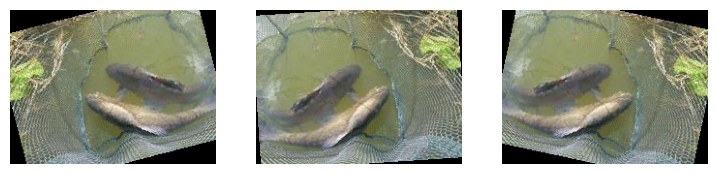





**Tench images shown in different orientations**

> **Note:** Augmentation is applied to training data only. During evaluation you want a fixed, repeatable measurement, and random inputs would make the same model score differently each time you evaluated it. Section 4 keeps augmentation in the training pipeline and out of the validation pipeline for this reason.  
>   
>



## Section 3: When Data Preparation Goes Wrong

Small preparation mistakes usually do not crash your program; they quietly degrade your results. This section reproduces three failures so you can recognize their symptoms. The first two are visible in the data itself, as differences in the numbers your model would receive. The third produces an actual error.

> **Note:** Seeing the full effect of the first two failures on a model's loss and accuracy requires a training loop, which is beyond the scope of this data-handling course. Here you make the *cause* visible in the data, and the explanation connects it to the training consequence.

### Step 8\. Compare unnormalized and normalized values

A common mistake is to convert images to floats but skip **Normalize**, leaving values in the 0-to-1 range instead of centered near zero. Build both versions of the same image and compare their statistics.

In [ ]:
to_float_pipeline = v2.Compose([
    v2.ToImage(),
    v2.Resize((160, 160), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
])
normalize = v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

unnormalized = to_float_pipeline(image)
normalized = normalize(unnormalized)

print("unnormalized: mean=%.3f min=%.3f max=%.3f" % (
    unnormalized.mean(), unnormalized.min(), unnormalized.max()))
print("normalized:   mean=%.3f min=%.3f max=%.3f" % (
    normalized.mean(), normalized.min(), normalized.max()))


**Sample Output:**

```
unnormalized: mean=0.412 min=0.000 max=1.000
normalized:   mean=-0.297 min=-2.118 max=2.472
```

The unnormalized image sits entirely in **\[0, 1\]** with a mean well above zero, so its values are one-sided. The normalized image is centered near zero with values on both sides. When inputs are large or one-sided rather than centered, the model may struggle to learn or, sometimes, even stop learning completely. Centering the inputs with **Normalize** is what avoids that.

### Step 9\. Compare mismatched train and evaluation normalization

The processing applied to training data and to evaluation data must match, except that training may add augmentation. If the two pipelines normalize differently, the model is evaluated on data in a range it never trained on. Reproduce that mismatch by normalizing the same image two different ways.


In [ ]:
train_norm = v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
val_norm_wrong = v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

base = to_float_pipeline(image)
train_version = train_norm(base)
val_version = val_norm_wrong(base)

print("train pipeline: mean=%.3f min=%.3f" % (train_version.mean(), train_version.min()))
print("val pipeline:   mean=%.3f min=%.3f" % (val_version.mean(), val_version.min()))


Here **val\_norm\_wrong** stands in for a validation pipeline that was set up with different statistics than the training pipeline.

**Sample Output:**

```
train pipeline: mean=-0.297 min=-2.118
val pipeline:   mean=-0.176 min=-1.000
```

The same image lands in two different numeric distributions depending on which pipeline processed it. A model that learned from the training distribution would see validation images shifted into an unfamiliar range, so its measured performance would look worse than the model really is. The fix is to define the two pipelines together and keep every step identical except augmentation, which Section 4 does. \[ \]

### Step 10\. Trigger type and shape mismatches

The third failure crashes, which makes it the easiest to catch. If your pipeline has no **Resize**, the images keep their original varying sizes, and the DataLoader cannot stack different-sized images into a batch. Reproduce the error by building a DataLoader over the raw, untransformed dataset and asking it for one batch.

> **Warning:** The next cell raises a **TypeError** on purpose, to show the failure. This is the expected result of this step, not a mistake in your code.


In [ ]:
bad_loader = DataLoader(raw_data, batch_size=32, shuffle=False)
images, labels = next(iter(bad_loader))


**next(iter(bad\_loader))** asks the DataLoader to build and return its first batch. Because **raw\_data** returns PIL images, the DataLoader cannot handle it.

**Sample Output:**

```
TypeError: default_collate: batch must contain tensors, numpy arrays, numbers,
dicts or lists; found <class 'PIL.Image.Image'>
```

The message names the cause directly: the batch contained PIL images, which cannot be stacked. In order to fix this, we use **ToImage** to convert PIL images into tensors and, once again, try to fetch a batch from the DataLoader.

> **Warning:** The next cell raises a **RuntimeError** on purpose, to show the failure. This is the expected result of this step, not a mistake in your code.


In [ ]:
tensor_data = Imagenette(
    root="data", split="train", size="160px", download=True,
    transform=v2.ToImage(),
)
still_bad_loader = DataLoader(tensor_data, batch_size=32, shuffle=False)
images, labels = next(iter(still_bad_loader))
print(images.shape)


**Sample Output:**

```
RuntimeError: stack expects each tensor to be equal size, but got [3, 160, 213] at entry 0 and [3, 160, 200] at entry 8
```

Now,  even though **tensor\_data** returns tensors, because of their different sizes, the DataLoader's default stacking step cannot combine them.

To truly fix this, load the same split with a transform that not only converts but also resizes each image, then draw a batch from a DataLoader over it.


In [ ]:
fixed_data = Imagenette(
    root="data", split="train", size="160px", download=True,
    transform=v2.Compose([
        v2.ToImage(),
        v2.Resize((160, 160), antialias=True),
        v2.ToDtype(torch.float32, scale=True),
    ]),
)
fixed_loader = DataLoader(fixed_data, batch_size=32, shuffle=False)
images, labels = next(iter(fixed_loader))
print(images.shape)


**Output:**

```
torch.Size([32, 3, 160, 160])
```

With every image converted to a tensor and resized to a common shape, the batch stacks cleanly into **\[32, 3, 160, 160\]**. Even when images are uniform, they must match the size the model expects; a model built for 160-by-160 inputs rejects a batch of a different size with a shape-related error. The fix in both cases is a **Resize** set to the shape the model was designed for.

## Section 4: Assembling the Full Pipeline

Everything now comes together into the two pipelines a real training script uses: one for training, with augmentation, and one for evaluation, without it. This section rebuilds **train\_data**, **val\_data**, and **train\_loader** with the full transforms and adds **val\_loader**, replacing the minimal preview transform from Lab 3\.

### Step 11\. Define the training and validation transforms

Define both pipelines side by side so the only difference between them is visible. The training pipeline includes the two augmentation transforms; the validation pipeline does not. Every other step is identical.


In [ ]:
train_transform = v2.Compose([
    v2.ToImage(),
    v2.Resize((160, 160), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),  # augmentation
    v2.RandomRotation(degrees=15),   # augmentation
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = v2.Compose([
    v2.ToImage(),
    v2.Resize((160, 160), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


The augmentation transforms sit after **Resize** and before **ToDtype**, so they act on the uniform-sized image. The conversion, resize, dtype, and normalization steps match exactly between the two pipelines, which is what keeps training and evaluation consistent. This cell produces no output.

### Step 12\. Reload each split with its transform

A Dataset applies a transform to every image it returns when you pass the transform as its **transform** argument. Reload the training split with **train\_transform** and the validation split with **val\_transform**, reusing the same names as before.


In [ ]:
train_data = Imagenette(root="data", split="train", size="160px",
                        download=True, transform=train_transform)
val_data = Imagenette(root="data", split="val", size="160px",
                      download=True, transform=val_transform)

print(len(train_data), len(val_data))


Reassigning **train\_data** and **val\_data** here replaces the versions from Lab 3 that used the minimal preview transform. Every sample drawn from **train\_data** is now augmented and preprocessed; every sample from **val\_data** is preprocessed without augmentation.

**Output:**

```
9469 3925
```

The training split has 9,469 samples and the validation split has 3,925.

### Step 13\. Wrap each dataset in a DataLoader

With both datasets producing uniform tensors, build one DataLoader for training and one for evaluation, using the settings established in Lab 3: shuffle and drop the last partial batch for training, and do neither for evaluation.


In [ ]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, drop_last=False)


Training uses **shuffle=True** so the model does not learn the stored order of the data, and **drop\_last=True** so every training batch is the full 32 samples. Evaluation uses **shuffle=False**, because order does not matter when you are only measuring, and **drop\_last=False**, because you want every validation sample counted, including the smaller final batch. This cell produces no output.

### Step 14\. Confirm the wiring

Draw one batch from each DataLoader and check its shape. This confirms the whole pipeline is connected correctly, from raw files through transforms to batched tensors.


In [ ]:
train_images, train_labels = next(iter(train_loader))
val_images, val_labels = next(iter(val_loader))

print(train_images.shape, train_labels.shape)
print(val_images.shape, val_labels.shape)


**next(iter(...))** pulls a single batch without looping over the whole DataLoader.

**Output:**

```
torch.Size([32, 3, 160, 160]) torch.Size([32])
torch.Size([32, 3, 160, 160]) torch.Size([32])
```

Each image batch is **\[batch, channels, height, width\]** and each label batch is **\[batch\]**, lined up in the same order. Both DataLoaders produce the same batch structure, which is exactly what a training loop consumes, one batch at a time.

## Cleanup

This lab does not create anything that must be torn down, and part of what it produces may be kept. There are no processes to stop and no services to remove.

**The data/ directory** holds the downloaded Imagenette files. On a local machine, keeping it means the next chapter's load is instant instead of downloading again. If you need to reclaim disk space, you may delete **data/imagenette2-160/**, but the dataset will download again the next time you load it.  
>   
On Google Colab the runtime is temporary. When your Colab session ends, the **data/** directory and all the objects are cleared. This is expected. In the next chapter you simply re-run the setup cells, which downloads the data again for the new session.

## Summary

In this lab you turned the raw Imagenette samples into model-ready batches. You applied **v2.ToImage**, **v2.ToDtype**, **v2.Resize**, and **v2.Normalize** one at a time and watched each change the sample, then chained them with **v2.Compose**. You added **v2.RandomHorizontalFlip** and **v2.RandomRotation** and saw the same image come out different on each draw, which is why augmentation belongs to training and not to evaluation. You reproduced three data-preparation failures: unnormalized values, mismatched train and evaluation normalization, and type and  shape mismatches that raised a **default\_collate** error until ToImage and  **Resize** fixed it. Finally you assembled the complete pipeline, reloading **train\_data** and **val\_data** with full training and validation transforms and wiring them into **train\_loader** and **val\_loader**, both delivering batches shaped **\[32, 3, 160, 160\]** with matching **\[32\]** labels. That connected pipeline of Dataset, transforms, and DataLoader is the structure a training loop reads from, and it is the complete data handling workflow this course set out to build.
